In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import os

# This is the safest way on Windows
local_path = r"C:\Users\MSI\Desktop\Thesis\Gemma-2B"

# Convert to absolute path and normalize
local_path = os.path.abspath(local_path)
print(f"Using absolute path: {local_path}")

# Verify the folder and files
if os.path.exists(local_path):
    print("✅ Folder exists!")
    files = os.listdir(local_path)
    print(f"Total files: {len(files)}")
    important = [f for f in files if any(x in f.lower() for x in ['model', 'config', 'tokenizer', 'phi3'])]
    print("Important files found:", important)
else:
    print("❌ Folder not found. Check the path above.")

print("\n" + "="*80)

# Load with extra safety
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    local_path,
    trust_remote_code=True,
    local_files_only=True
)

from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    local_path,
    trust_remote_code=True,
    local_files_only=True
)

print(config)
print(type(config))

print("Loading model... (expect 30-90 seconds on CPU)")
model = AutoModelForCausalLM.from_pretrained(
    local_path,
    trust_remote_code=True,
    #device_map="cpu",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
    local_files_only=True
)

print("\n🎉 SUCCESS! Gemma-2B is loaded from local folder.")

# Show the architecture
config = model.config
print("\n" + "="*80)
print("=== Gemma-2B Architecture Summary ===")
print(f"Hidden size (d_model)          : {config.hidden_size}")
print(f"Number of Transformer layers   : {config.num_hidden_layers}")
print(f"MLP intermediate size          : {config.intermediate_size}")
print(f"Attention heads                : {config.num_attention_heads}")
print(f"Key-Value heads (GQA)          : {getattr(config, 'num_key_value_heads', config.num_attention_heads)}")
print(f"Vocab size                     : {config.vocab_size}")
print(f"Max context length             : {config.max_position_embeddings} tokens")
print(f"Activation                     : {config.hidden_act}")
print(f"Position encoding              : RoPE")
print(f"Normalization                  : RMSNorm")

Using absolute path: C:\Users\MSI\Desktop\Thesis\Gemma-2B
✅ Folder exists!
Total files: 8
Important files found: ['config.json', 'model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors', 'model.safetensors.index.json', 'tokenizer.json', 'tokenizer.model', 'tokenizer_config.json']

Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


GemmaConfig {
  "architectures": [
    "GemmaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 2,
  "dtype": "bfloat16",
  "eos_token_id": 1,
  "head_dim": 256,
  "hidden_act": "gelu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 16384,
  "max_position_embeddings": 8192,
  "model_type": "gemma",
  "num_attention_heads": 8,
  "num_hidden_layers": 18,
  "num_key_value_heads": 1,
  "pad_token_id": 0,
  "rms_norm_eps": 1e-06,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.5.0",
  "use_bidirectional_attention": null,
  "use_cache": true,
  "vocab_size": 256000
}

<class 'transformers.models.gemma.configuration_gemma.GemmaConfig'>
Loading model... (expect 30-90 seconds on CPU)


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]


🎉 SUCCESS! Gemma-2B is loaded from local folder.

=== Gemma-2B Architecture Summary ===
Hidden size (d_model)          : 2048
Number of Transformer layers   : 18
MLP intermediate size          : 16384
Attention heads                : 8
Key-Value heads (GQA)          : 1
Vocab size                     : 256000
Max context length             : 8192 tokens
Activation                     : gelu
Position encoding              : RoPE
Normalization                  : RMSNorm


In [5]:
print("\n" + "="*80)
print("=== Detailed Parameter Analysis ===")

hidden_size = config.hidden_size
num_layers = config.num_hidden_layers
intermediate_size = config.intermediate_size
vocab_size = config.vocab_size

# 🔹 Embedding parameters
embedding_params = vocab_size * hidden_size

# 🔹 Attention parameters per layer (Q, K, V, Output)
attention_params_per_layer = 4 * (hidden_size * hidden_size)

# 🔹 MLP parameters per layer
mlp_params_per_layer = (hidden_size * intermediate_size) + (intermediate_size * hidden_size)

# 🔹 Total per transformer block
params_per_block = attention_params_per_layer + mlp_params_per_layer

# 🔹 Total transformer parameters
total_transformer_params = params_per_block * num_layers

# 🔹 Total model params (approx)
total_params = total_transformer_params + embedding_params

print(f"Embedding parameters           : {embedding_params:,}")
print(f"Attention params per layer     : {attention_params_per_layer:,}")
print(f"MLP params per layer           : {mlp_params_per_layer:,}")
print(f"Total params per block         : {params_per_block:,}")
print(f"Total transformer params       : {total_transformer_params:,}")
print(f"Estimated total parameters     : {total_params:,}")


=== Detailed Parameter Analysis ===
Embedding parameters           : 524,288,000
Attention params per layer     : 16,777,216
MLP params per layer           : 67,108,864
Total params per block         : 83,886,080
Total transformer params       : 1,509,949,440
Estimated total parameters     : 2,034,237,440


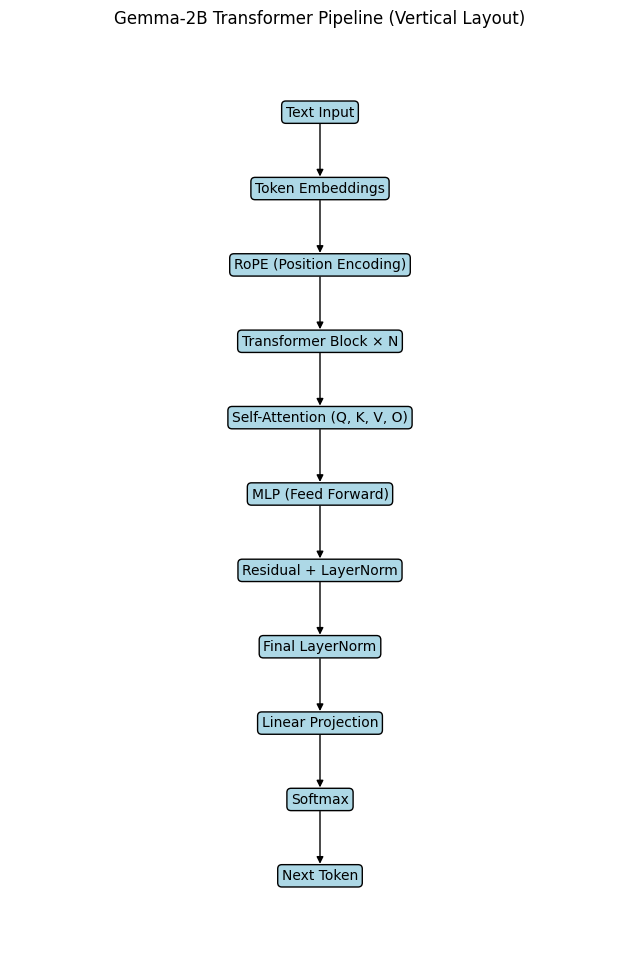

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

nodes = [
    "Text Input",
    "Token Embeddings",
    "RoPE (Position Encoding)",
    "Transformer Block × N",
    "Self-Attention (Q, K, V, O)",
    "MLP (Feed Forward)",
    "Residual + LayerNorm",
    "Final LayerNorm",
    "Linear Projection",
    "Softmax",
    "Next Token"
]

edges = [
    ("Text Input", "Token Embeddings"),
    ("Token Embeddings", "RoPE (Position Encoding)"),
    ("RoPE (Position Encoding)", "Transformer Block × N"),
    ("Transformer Block × N", "Self-Attention (Q, K, V, O)"),
    ("Self-Attention (Q, K, V, O)", "MLP (Feed Forward)"),
    ("MLP (Feed Forward)", "Residual + LayerNorm"),
    ("Residual + LayerNorm", "Final LayerNorm"),
    ("Final LayerNorm", "Linear Projection"),
    ("Linear Projection", "Softmax"),
    ("Softmax", "Next Token")
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize=(8, 12))

# 🔥 KEY FIX: vertical layout
pos = {node: (0, -i) for i, node in enumerate(nodes)}

# Draw edges
nx.draw_networkx_edges(G, pos, arrows=True)

# Draw rectangular nodes manually
for node, (x, y) in pos.items():
    plt.text(
        x, y,
        node,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#add8e6",
            edgecolor="black"
        )
    )

plt.title("Gemma-2B Transformer Pipeline (Vertical Layout)")
plt.axis("off")
plt.show()